In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_pickle("LabDelSole.pickle")

colori = sns.color_palette("pastel")

In [2]:
df_t=pd.DataFrame()

df_t["tipologia"]=df["info","tipologia"]
df_t["mio design"]=df["info","design mio"]
df_t["tot"] = df["passaparola"].sum(axis=1) + df["mercatino"].sum(axis=1) + df["info", "regalate"] + df["info", "rimaste"]

df_def = df_t.groupby(["tipologia", "mio design"], as_index=False)["tot"].sum()
df_def = df_def.rename(columns={"tot": "pezzi"})
df_def["design"] = df_def["mio design"].map({True: "Originale", False: "Non originale"})

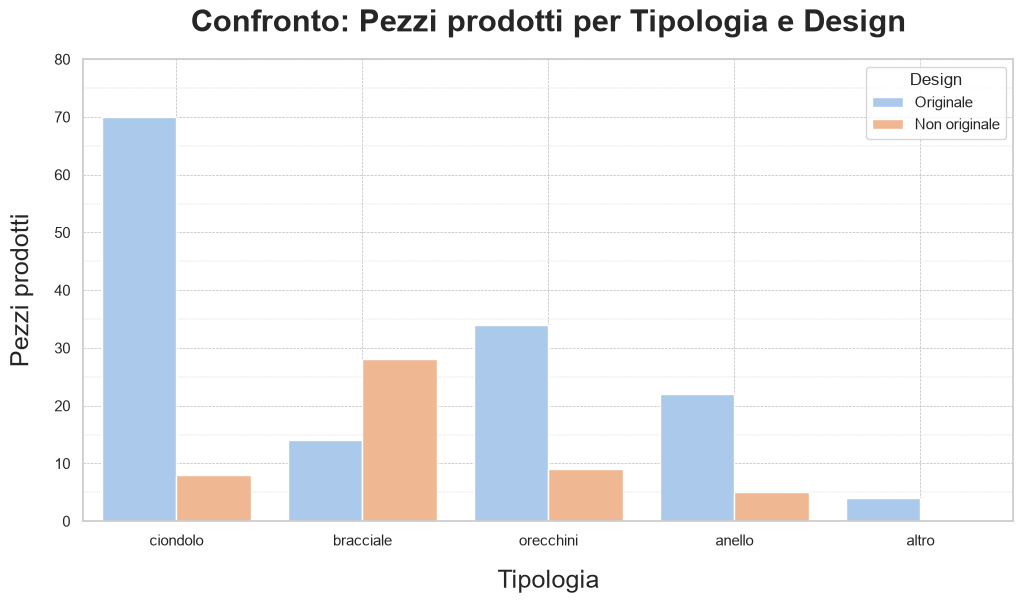

In [3]:
sns.set(style="whitegrid", font_scale=1)
fig, ax = plt.subplots(figsize=(12, 6))

ordine = ["ciondolo", "bracciale", "orecchini", "anello", "altro"]

sns.barplot(
    data=df_def,
    x="tipologia",
    order=ordine,
    y="pezzi",
    hue="design",
    hue_order=["Originale", "Non originale"],
    palette={"Originale": colori[0], "Non originale": colori[1]}
)
ax.set_facecolor("#FFFFFF")
ax.grid(True, color="#BBBBBB", linewidth=0.5, linestyle="--")
ax.grid(True, axis="y", which="minor", linewidth=0.3, linestyle="--")

ax.yaxis.set_major_locator(plt.MultipleLocator(10))
ax.yaxis.set_minor_locator(plt.MultipleLocator(5))
ax.set_ylim(0, 80)

ax.set_title("Confronto: Pezzi prodotti per Tipologia e Design", pad=20, fontsize=22, fontweight="bold")
ax.set_xlabel("Tipologia", fontsize=18, fontweight="normal", labelpad=15)
ax.set_ylabel("Pezzi prodotti", fontsize=18, fontweight="normal", labelpad=15)

ax.legend(title="Design", loc="upper right")

plt.savefig("Immagini/Tipologia-design.svg", bbox_inches = "tight", pad_inches = 0.1, transparent = False)
plt.savefig("Immagini/Tipologia-design.png", bbox_inches = "tight", pad_inches = 0.1, transparent = False);